--- First 5 Rows of Dataset ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   s

None

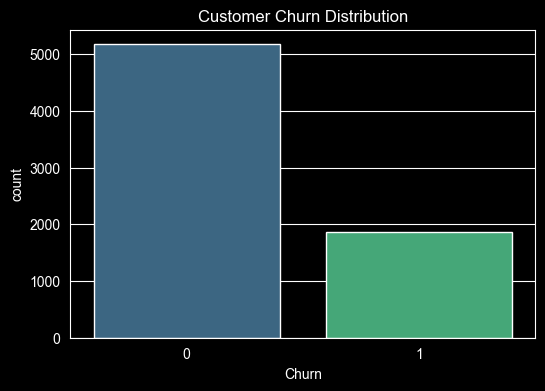

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.51      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409

--- Business Interpretation via SHAP ---


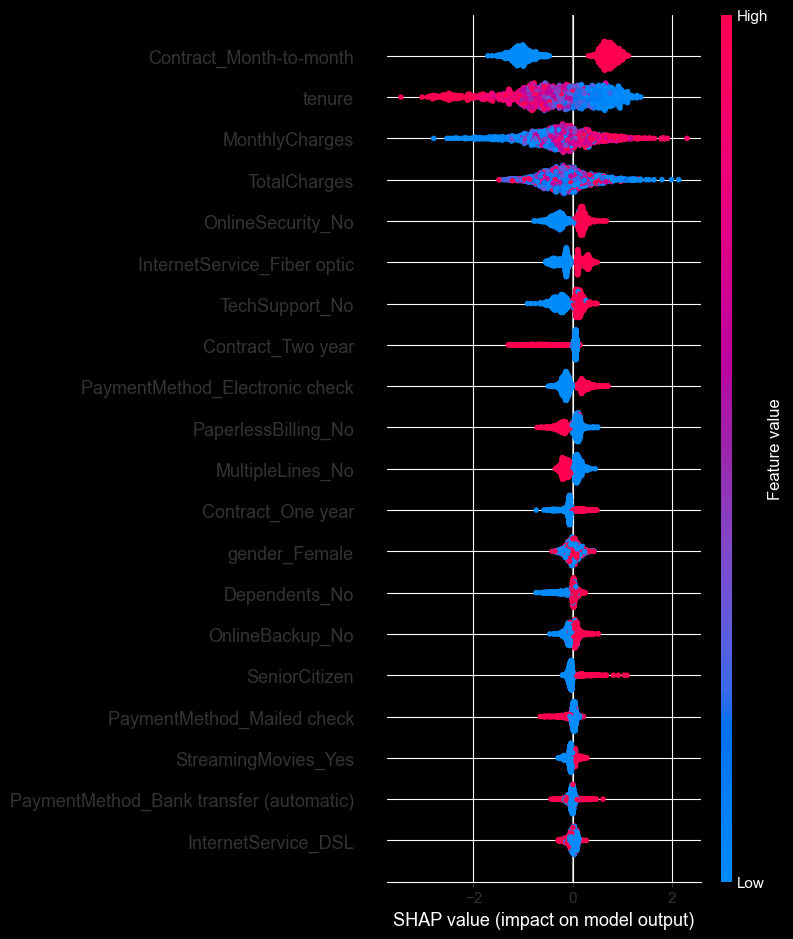

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap

# Initialize JS visualization for SHAP
shap.initjs()

# ==========================================
# 1. LOAD CUSTOMER DATASET
# ==========================================
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("--- First 5 Rows of Dataset ---")
display(df.head())

# --- QUICK DATA CLEANING ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop('customerID', axis=1)

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("--- Data Info ---")
display(df.info())

plt.figure(figsize=(6,4))
# FIX: Added hue='Churn' and legend=False for the new Seaborn syntax
sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis', legend=False)
plt.title("Customer Churn Distribution")
plt.show()

# ==========================================
# 3. FEATURE ENGINEERING & PIPELINE
# ==========================================
X = df.drop('Churn', axis=1)
y = df['Churn']

# FIX: Changed how categorical columns are selected to avoid Pandas warnings
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(exclude=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 4. TRAIN CHURN PREDICTION MODEL
# ==========================================
# FIX: Removed use_label_encoder=False for the new XGBoost version
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# ==========================================
# 5. BUSINESS INTERPRETATION
# ==========================================
print("--- Business Interpretation via SHAP ---")

xgb_model = model_pipeline.named_steps['classifier']
X_train_transformed = model_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)

cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(encoded_cat_cols)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names)